In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sys
from wave_approx import *

%load_ext autoreload
%autoreload 2
"""
basic approx.:
    Poisson approximation of Triplet rule + rate homeostasis
    Wilson-Cowan V1
exact0: basic approx.
approx3: basic approx + update W only between sweeps (fixed within sweep)
approx2: approx3 + firing rate follows input instantaneously
approx1: approx2 + ignore W-r interaction within the sweep
""";

/home/wd/repo/spont_approx/wave_approx.py:6: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
quad = False
fork_ivp = True
n = 5
p = np.linspace(0.05,0.95,n)
l = 4
rLTD = 1.0
r0 = 6/rLTD
rx = 20
tau = 1
d = 3
v = 4
A = 0.025
k = 0.114*0.017*A
tau_m = 0.02
gL = 40
w0 = 0.3
cap = 12
dt = 1.118e-3

y0 = np.array([0, 0])
y1 = np.array([0, 0])
y2 = np.array([0, 0])
y3 = np.array([0, 0, 0])

L = 2*l*np.sqrt(2) + 2*d
T = L/v
print(f'T = {T:.3f}s')
# first T
nt = int(T/dt)+2
t = np.arange(nt)*dt
print(f'dt = {dt:.3e}, t[-1] = {t[-1]}')
nx = 2*l+2
x = np.linspace(0,2*l, nx)
w_init = w0*np.ones(nx)

T = 4.328s
dt = 1.118e-03, t[-1] = 4.328896


k = 4.845e-05, coef_0 = 1.938e-02, coef_1 = 48.0


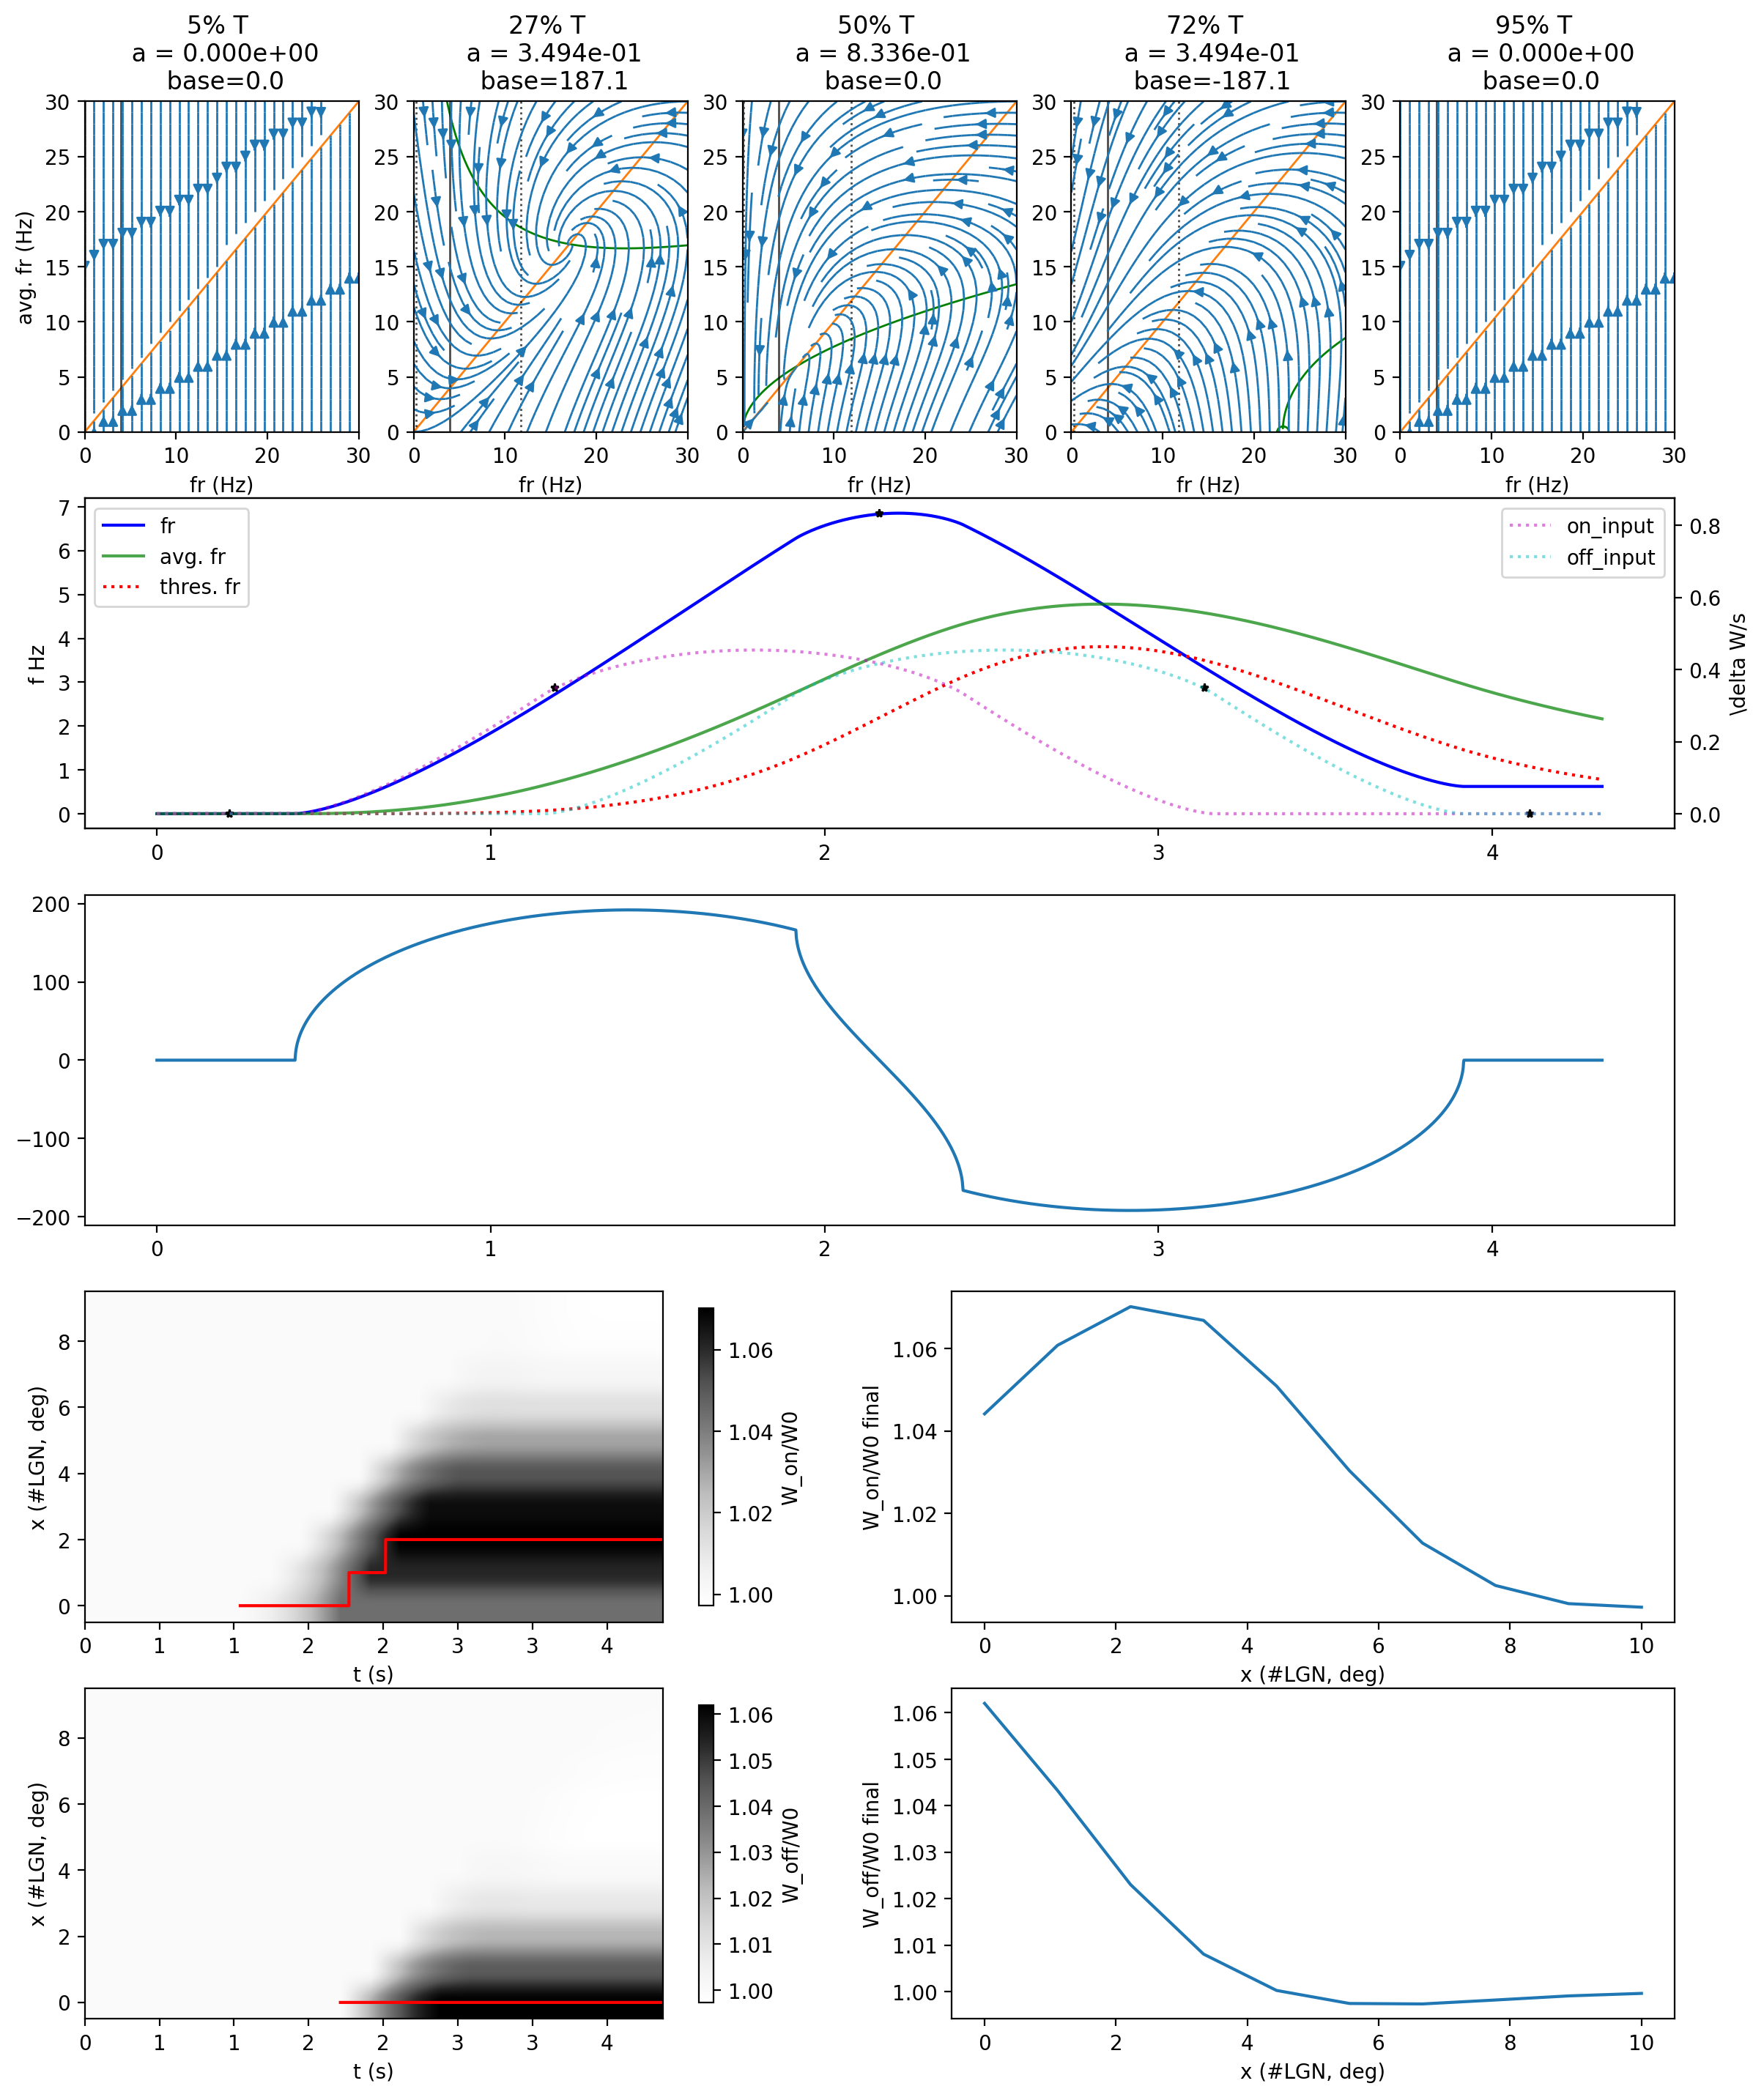

In [3]:
r_max = 30
r = np.linspace(0, r_max, 30)
rbar = np.linspace(0, r_max, 30)
# solve approx2, plot trace
fig = plt.figure(figsize = (14/5*n,3.4*5), dpi = 200)
# phase plane
a = k*rx*rx*int_circle_chord(T*p, v=v, d=d, l=l)
for i in range(n):
    ax = fig.add_subplot(5,n,i+1)
    phase_plane(get_dF2_III(w0, w0, True, half_circle_height, iint_circle_chord, T*p[i], k = k, r0 = r0, l = l, d = d, v = v, rx = rx, tau = tau, gL = gL), r, rbar, ax = ax)
    _r = np.linspace(0,r[-1], 1000)
    _rbar, ro = nullcline2_III(_r, w0, w0, True, half_circle_height, iint_circle_chord, T*p[i], k, l, d, v, r0, rx, gL)
    ax.plot(_r, _rbar, 'g', lw = 1, alpha = 1, zorder = 0)
    if ro is not None:
        ax.plot(ro, 0, 'og', fillstyle = 'none', alpha = 1, zorder = 0)
    ax.plot(_r, _r, lw = 1, alpha = 1, zorder = 0)
    ax.plot(2/3*r0+np.zeros_like(rbar), rbar, 'k', lw = 1, alpha = 0.7, zorder = 0)
    if a[i] > 1/r0:
        ax.plot(r0 + np.sqrt(r0*r0-1/a[i]) + np.zeros_like(rbar), rbar, ':k', lw = 1, alpha = 0.7, zorder = 0)
        ax.plot(r0 - np.sqrt(r0*r0-1/a[i]) + np.zeros_like(rbar), rbar, ':k', lw = 1, alpha = 0.7, zorder = 0)
    x_bot, x_top = get_xrange(T*p[i],v,d,l)
    ax.set_title(f'{p[i]*100:.0f}% T \n a = {a[i]:.3e}\n base={2*v*rx*w0*(half_circle_height(x_top, l) - half_circle_height(x_bot, l)):.1f}')
    ax.set_xlim(r[0], r[-1])
    ax.set_ylim(rbar[0], rbar[-1])
    if i == 0:
        ax.set_ylabel('avg. fr (Hz)')
    ax.set_xlabel('fr (Hz)')

ax = fig.add_subplot(5,1,2)

sol2 = solve_ivp(get_approx2_III(w0, w0, True, half_circle_height, iint_circle_chord, k = k, l = l, d = d, v = v, r0 = r0, rx = rx, gL = gL, tau = tau), t, y2)
    
ax.plot(sol2.t, sol2.y[0,:], 'b', label = 'fr')
ax.plot(sol2.t, sol2.y[1,:], 'g', label = 'avg. fr', alpha = 0.7)
print(f'k = {k:.3e}, coef_0 = {k*rx*rx:.3e}, coef_1 = {2*v*rx*w0}')
ax.plot(sol2.t, np.power(sol2.y[1,:],2)/r0, ':r', label = 'thres. fr')

ax.set_ylabel('f Hz')
ax.legend(loc = 'upper left')
ax = ax.twinx()
ax.plot(T*p, a, '*k', ms = 4)
ax.plot(t, k*rx*rx*int_circle_chord(t, v=v, d=d, l=l, nd=1), ':m', alpha = 0.5, label = 'on_input')
ax.plot(t, k*rx*rx*int_circle_chord(t-d/v, v=v, d=d, l=l, nd=1), ':c', alpha = 0.5, label = 'off_input')
ax.legend()
ax.set_ylabel('\delta W/s')

ax = fig.add_subplot(5,1,3)
x_bot, x_top = get_xrange(t,v,d,l, 1)
Gt = half_circle_height(x_top, l) - half_circle_height(x_bot, l)
x_bot, x_top = get_xrange(t-d/v,v,d,l, 1)
Gt += half_circle_height(x_top, l) - half_circle_height(x_bot, l)
Gt *= 2*v*rx*w0
ax.plot(t, Gt)

ax0 = fig.add_subplot(5,2,7)
ax1 = fig.add_subplot(5,2,8)
# plot W over time
w2 = next_W(t,w_init,sol2.y[0,:],sol2.y[1,:], k,l,d,v,rx,r0,nd=1, end_only = False)
w2[w2>w0*cap] = w0*cap
show_w_over_t(w2/w0, dt, 't (s)', 'W_on/W0', l, ax = [ax0, ax1])
ax0 = fig.add_subplot(5,2,9)
ax1 = fig.add_subplot(5,2,10)
w2 = next_W(t-d/v,w_init,sol2.y[0,:],sol2.y[1,:], k,l,d,v,rx,r0,nd=1, end_only = False)
w2[w2>w0*cap] = w0*cap
show_w_over_t(w2/w0, dt, 't (s)', 'W_off/W0', l, ax = [ax0, ax1])

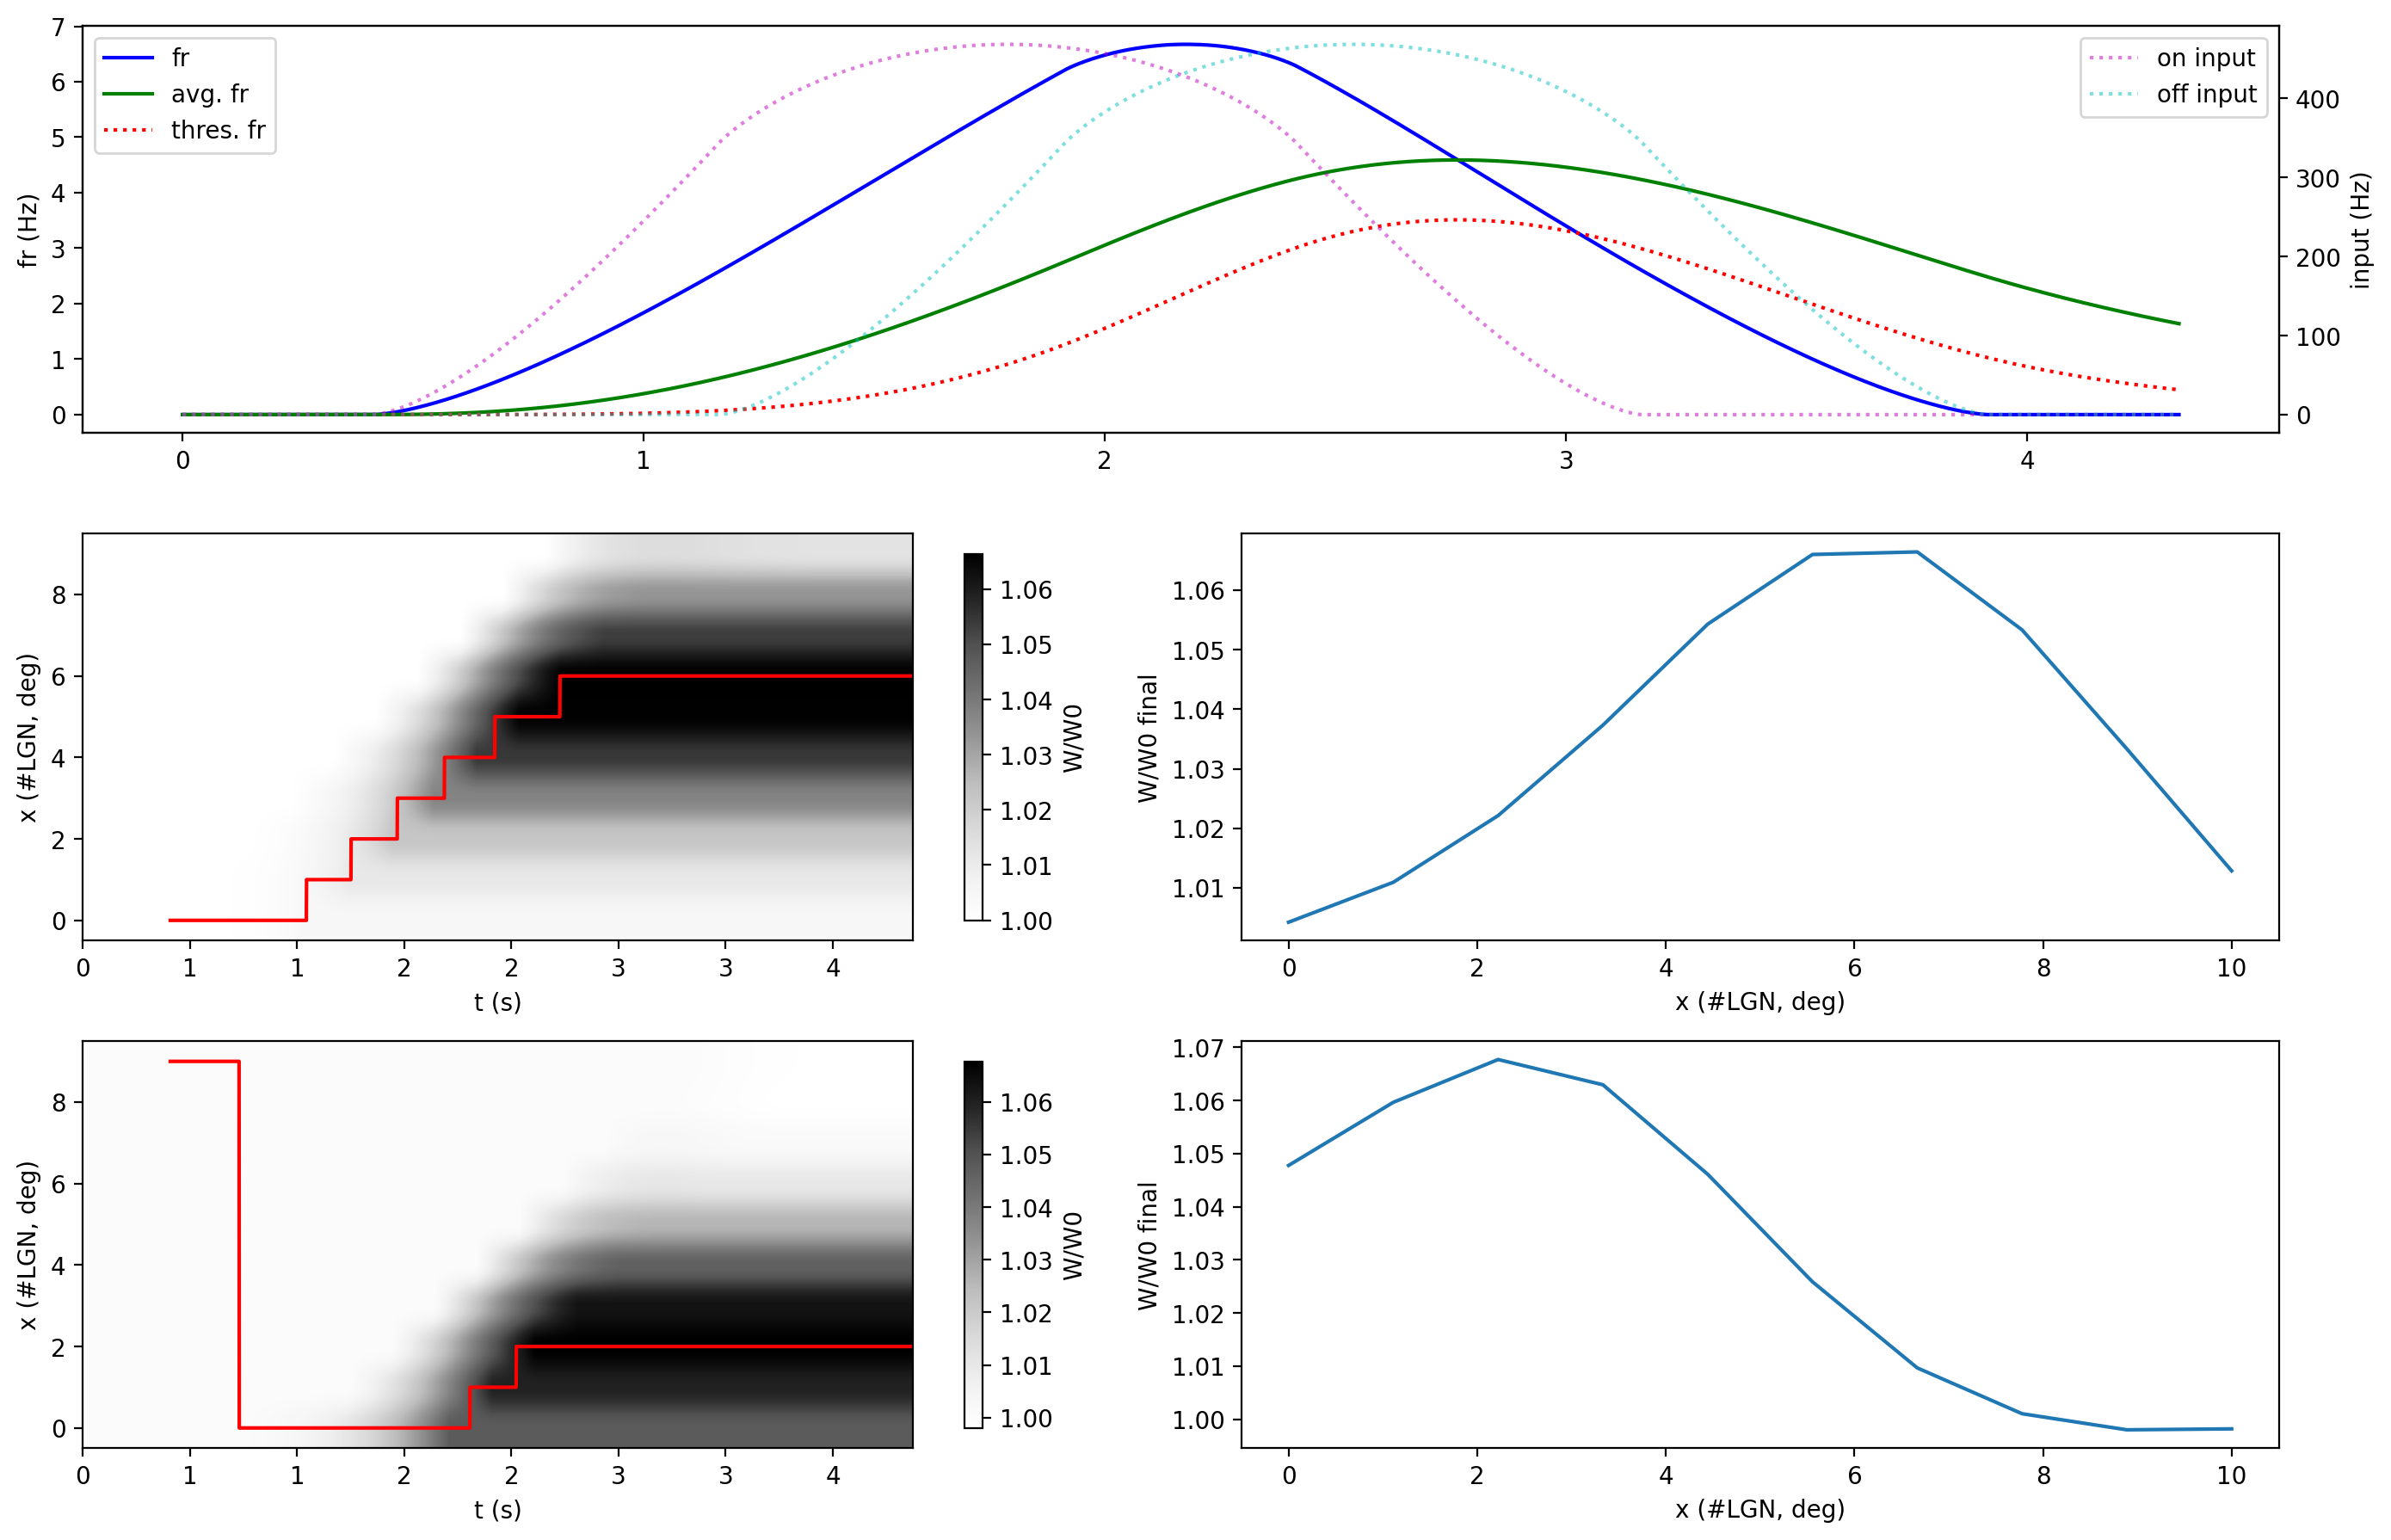

In [4]:
# solve exact1, plot trace
fig = plt.figure(figsize = (14,3.0*3), dpi = 200)
ax = fig.add_subplot(3,1,1)
y0_w = np.hstack((y0, w_init, w_init))
if quad:
    func = half_circle_height
else:
    func = iint_circle_chord
    
_sol0 = solve_ivp(get_exact1_III(func, dt, w0*cap, k = k, l = l, d = d, v = v, r0 = r0, rx = rx, gain = 1/gL, tau = tau, quad = quad), t, y0_w, cap = w0*cap)
_sol0 = solve_ivp(get_exact1_III(func, dt, w0*cap, k = k, l = l, d = d, v = v, r0 = r0, rx = rx, gain = 1/gL, tau = tau, quad = quad), t, y0_w, cap = w0*cap)
#sol0 = sp.integrate.solve_ivp(get_exact1_III, [0, t[-1]], y0_w, vectorized = True, t_eval = t, method = 'RK45')
    
#ax.plot(sol0.t, sol0.y[0,:], ':b', label = 'fr')
#ax.plot(sol0.t, sol0.y[1,:], ':r', label = 'avg. fr')
ax.plot(_sol0.t, _sol0.y[0,:], 'b', label = 'fr')
ax.plot(_sol0.t, _sol0.y[1,:], 'g', label = 'avg. fr')
ax.plot(_sol0.t, np.power(_sol0.y[1,:],2)/r0, ':r', label = 'thres. fr')

ax.set_ylabel('fr (Hz)')
ax.legend(loc = 'upper left')
ax = ax.twinx()
ax.plot(t, rx*int_circle_chord(t, v=v, d=d, l=l, nd = 1), ':m', alpha = 0.5, label = 'on input')
ax.plot(t, rx*int_circle_chord(t-d/v, v=v, d=d, l=l, nd = 1), ':c', alpha = 0.5, label = 'off input')
ax.legend()
ax.set_ylabel('input (Hz)')
# plot w
ax0 = fig.add_subplot(3,2,3)
ax1 = fig.add_subplot(3,2,4)
show_w_over_t(_sol0.y[2:2+nx,:]/w0, dt, 't (s)', 'W/W0', l, ax = [ax0, ax1])
ax0 = fig.add_subplot(3,2,5)
ax1 = fig.add_subplot(3,2,6)
show_w_over_t(_sol0.y[2+nx:2+2*nx,:]/w0, dt, 't (s)', 'W/W0', l, ax = [ax0, ax1])
fig.tight_layout()